In [ ]:
!pip install ucimlrepo scikit-fuzzy scipy seaborn matplotlib scikit-learn


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.8/36.5 MB 5.6 MB/s eta 0:00:07
   -- ------------------------------------- 2.1/36.5 MB 6.5 MB/s eta 0:00:06
   ---- ----------------------------------- 3.7/36.5 MB 6.7 MB/s eta 0:00:05
   ----- ---------------------------------- 4.7/36.5 MB 6.4 MB/s eta 0:00:05
   ------ --------------------------------- 5.8/36.5 MB 6.0 MB/s eta 0:00:06
   ------- -------------------------------- 7.1/36.5 MB 6.0 MB/s eta 0:00:05
   --------- ------------------------------ 8.7/36.5 MB 6.2 MB/s eta 0:00:05
   ---------- ----------------------------- 10.0/36.5 MB 6.2 MB/s eta 0:00:05
   ------------ --------------------------- 11.5/36.5 MB 6.3 MB/s eta 0:00:04
   -------------- ------------------------- 12.8/36.5 MB 6.3 MB/s eta 0:00:04
   --------------- ------------------------ 14.2/36.5 MB 6.3 MB/s eta 0:00:04
 


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Pada tahap persiapan, dilakukan instalasi package ucimlrepo sebagai sumber pengambilan dataset dan scikit-fuzzy untuk mendukung eksperimen clustering lanjutan. Instalasi ini memastikan seluruh library yang dibutuhkan untuk preprocessing, clustering dasar, dan clustering lanjutan tersedia dan dapat digunakan.

Import Library

In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
import scipy.cluster.hierarchy as sch

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA


ModuleNotFoundError: No module named 'sklearn'

Mengimpor library  untuk analisis clustering meliputi manipulasi data (pandas, numpy), visualisasi (matplotlib, seaborn), pengambilan dataset (ucimlrepo), preprocessing (RobustScaler), metode clustering (K-Means, Hierarchical, DBSCAN, Fuzzy C-Means, Spectral), evaluasi cluster (Silhouette Score), penentuan parameter DBSCAN (NearestNeighbors), serta visualisasi cluster dengan PCA.

# Load Data

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X = wine.data.features
y = wine.data.targets

# metadata
print(wine.metadata)

# variable information
print(wine.variables)


{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

Dataset yang digunakan terdiri dari 178 observasi, dan 13 variabel numerik merepresentasikan karakteristik kimia wine seperti kadar alkohol, kandungan fenol, intensitas warna, dan komposisi mineral. Dataset ini sesuai untuk analisis clustering karena setiap fitur menggambarkan profil kimia wine yang dapat digunakan untuk mengelompokkan sampel berdasarkan kemiripan karakteristiknya.

In [ ]:
df = pd.concat([X, y], axis=1) #gabungkan
df

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


Menggabungkan data fitur X dan target y menjadi satu dataframe df menggunakan pd.concat() dengan axis=1 (gabung per kolom). Hasilnya dataset memiliki 178 baris dan 14 kolom (13 fitur + 1 class), lalu df ditampilkan untuk melihat struktur data awal.

# Data Understanding

informasi data

In [ ]:
info_df = pd.DataFrame({
    "Kolom": df.columns,
    "Tipe Data": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
})

info_df

,Kolom,Tipe Data,Non-Null Count
0,Alcohol,float64,178
1,Malicacid,float64,178
2,Ash,float64,178
3,Alcalinity_of_ash,float64,178
4,Magnesium,int64,178
5,Total_phenols,float64,178
6,Flavanoids,float64,178
7,Nonflavanoid_phenols,float64,178
8,Proanthocyanins,float64,178
9,Color_intensity,float64,178


Menampilkan informasi tiap variabel, meliputi nama kolom, tipe data, jumlah data non-null, dan missing value. Output menunjukkan seluruh 14 variabel memiliki 178 data lengkap tanpa missing value,

statistik deskriptif

In [ ]:
desc = df.describe().T
desc = desc.rename(columns={
    "mean": "Mean",
    "std": "Std Dev",
    "min": "Min",
    "25%": "Q1",
    "50%": "Median",
    "75%": "Q3",
    "max": "Max"
})

desc

,count,Mean,Std Dev,Min,Q1,Median,Q3,Max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malicacid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Menghitung statistik deskriptif tiap variabel, lalu mengganti nama kolom agar lebih mudah dibaca (Mean, Std Dev, Q1, Median, Q3). Jadi, output menampilkan ringkasan distribusi data seperti rata-rata, sebaran, dan rentang nilai tiap fitur untuk memahami karakteristik dataset sebelum clustering.

# Data Preprocessing

cek missing value

In [ ]:
df.isnull().sum()

,0
Alcohol,0
Malicacid,0
Ash,0
Alcalinity_of_ash,0
Magnesium,0
Total_phenols,0
Flavanoids,0
Nonflavanoid_phenols,0
Proanthocyanins,0
Color_intensity,0


Berdasarkan pemeriksaan awal, tidak ditemukan missing value sehingga data dapat langsung digunakan tanpa proses imputasi

cek outlier

In [ ]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR)))

print("Jumlah outlier tiap fitur:")
print(outliers.sum())

Jumlah outlier tiap fitur:
Alcohol                         0
Malicacid                       3
Ash                             3
Alcalinity_of_ash               4
Magnesium                       4
Total_phenols                   0
Flavanoids                      0
Nonflavanoid_phenols            0
Proanthocyanins                 2
Color_intensity                 4
Hue                             1
0D280_0D315_of_diluted_wines    0
Proline                         0
dtype: int64


Mendeteksi outlier pada setiap fitur menggunakan metode IQR (Interquartile Range), yaitu data yang berada di bawah batas Q1 − 1.5×IQR atau di atas Q3 + 1.5×IQR dianggap outlier. Output menunjukkan jumlah outlier di tiap variabel, misalnya Magnesium, Alcalinity of Ash, dan Color Intensity masing-masing memiliki 4 outlier, sedangkan beberapa fitur seperti Alcohol, Flavanoids, dan Proline tidak memiliki outlier.

Namun, outlier tidak dihapus karena jumlahnya kecil dan telah ditangani secara implisit melalui penggunaan scaling robust.

scalling

In [ ]:
X = df.drop(columns=['class']) #hapus kolom kelas

# scaling
scaler = RobustScaler()
X_scaled_array = scaler.fit_transform(X)

# convert ke DataFrame
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

X_scaled

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050
1,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090
2,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728
3,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603
4,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.501901,2.557432,0.258993,0.232558,-0.157895,-0.638298,-0.913174,1.074627,-0.707143,1.010067,-0.962963,-0.843813,0.137255
174,0.266160,1.381757,0.345324,0.813953,0.210526,-0.524823,-0.829341,0.537313,-0.207143,0.875839,-0.785185,-0.989858,0.157895
175,0.167300,1.631757,-0.287770,0.116279,1.157895,-0.723404,-0.865269,0.537313,-0.292857,1.848993,-1.111111,-0.989858,0.333333
176,0.091255,0.489865,0.028777,0.116279,1.157895,-0.666667,-0.871257,1.134328,-0.135714,1.546980,-1.081481,-0.941176,0.343653


Menghapus kolom class karena label asli tidak digunakan dalam clustering, sehingga hanya 13 fitur numerik yang dipakai. Selanjutnya dilakukan RobustScaler untuk normalisasi agar perbedaan skala antar fitur (misalnya Proline jauh lebih besar dari Hue) tidak mendominasi proses clustering, sekaligus lebih tahan terhadap outlier.

Output X_scaled menunjukkan seluruh variabel sudah ditransformasi ke skala yang sebanding dengan nilai terpusat di sekitar 0; nilai positif menunjukkan observasi di atas median, sedangkan nilai negatif di bawah median.

In [ ]:
# Bandingkan statistik sebelum vs sesudah scaling
before = X.describe().T[['min','25%','50%','75%','max']]
after = X_scaled.describe().T[['min','25%','50%','75%','max']]

compare = pd.concat([before, after], axis=1)
compare.columns = [
    'min_before','Q1_before','median_before','Q3_before','max_before',
    'min_after','Q1_after','median_after','Q3_after','max_after'
]

compare.round(2)

,min_before,Q1_before,median_before,Q3_before,max_before,min_after,Q1_after,median_after,Q3_after,max_after
Alcohol,11.03,12.36,13.05,13.68,14.83,-1.54,-0.52,0.0,0.48,1.35
Malicacid,0.74,1.60,1.87,3.08,5.80,-0.76,-0.18,-0.0,0.82,2.66
Ash,1.36,2.21,2.36,2.56,3.23,-2.88,-0.43,0.0,0.57,2.50
Alcalinity_of_ash,10.60,17.20,19.50,21.50,30.00,-2.07,-0.53,0.0,0.47,2.44
Magnesium,70.00,88.00,98.00,107.00,162.00,-1.47,-0.53,0.0,0.47,3.37
Total_phenols,0.98,1.74,2.36,2.80,3.88,-1.30,-0.58,0.0,0.42,1.44
Flavanoids,0.34,1.20,2.13,2.88,5.08,-1.07,-0.56,0.0,0.44,1.76
Nonflavanoid_phenols,0.13,0.27,0.34,0.44,0.66,-1.25,-0.42,0.0,0.58,1.91
Proanthocyanins,0.41,1.25,1.56,1.95,3.58,-1.64,-0.44,-0.0,0.56,2.89
Color_intensity,1.28,3.22,4.69,6.20,13.00,-1.14,-0.49,0.0,0.51,2.79


Perbandingan statistik menunjukkan bahwa sebelum scaling, rentang nilai antar fitur sangat berbeda, misalnya Proline jauh lebih besar dibanding Hue, sehingga berpotensi mendominasi clustering. Setelah Robust Scaling, seluruh fitur terpusat di sekitar median (≈0) dengan rentang yang lebih seimbang (sekitar -1 hingga 1). Nilai maksimum juga menjadi lebih terkendali (misalnya Proline dari 1680 menjadi ±2.08), menandakan pengaruh outlier berkurang tanpa dihapus. Dengan demikian, scaling membuat kontribusi tiap fitur lebih adil dalam proses clustering.

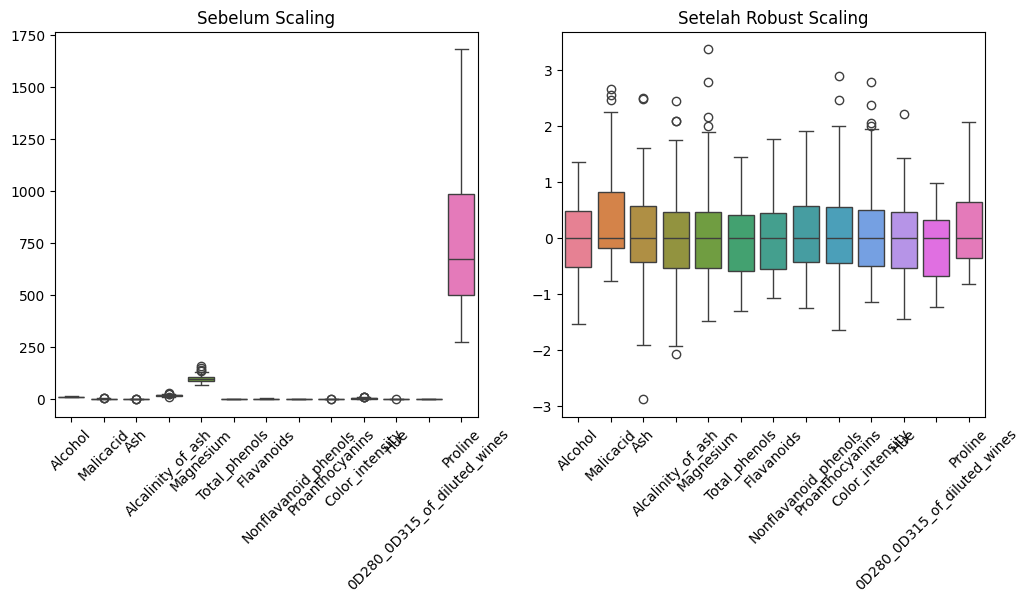

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=X)
plt.title("Sebelum Scaling")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(data=X_scaled)
plt.title("Setelah Robust Scaling")
plt.xticks(rotation=45)

plt.show()

Visualisasi boxplot sebelum scaling menunjukkan perbedaan skala yang besar, terutama pada *Proline* yang jauh lebih tinggi sehingga berpotensi mendominasi clustering, serta adanya beberapa outlier. Setelah Robust Scaling, semua fitur menjadi lebih seimbang dengan median mendekati 0 dan distribusi lebih stabil. Outlier masih ada, namun pengaruhnya berkurang, sehingga tidak perlu dihapus karena sudah ditangani secara implisit oleh proses scaling.

### visualisasi awal (EDA)

pca

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_vis = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_vis['class'] = df['class']

X_vis

,PC1,PC2,class
0,2.224400,1.122175,1
1,1.513203,-0.455374,1
2,1.694732,0.988510,1
3,2.283501,1.951367,1
4,0.507457,0.948706,1
...,...,...,...
173,-2.446388,1.367023,3
174,-1.768713,1.167196,3
175,-1.738909,1.861535,3
176,-1.491012,1.568964,3


In [ ]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.32853032 0.19681405]
Total Variance Explained: 0.5253443688085926


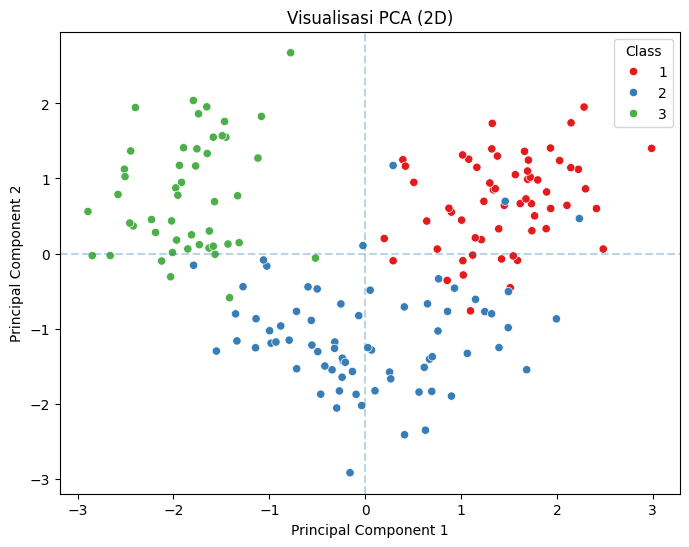

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='class',
    palette='Set1',
    data=X_vis
)
plt.title('Visualisasi PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.axhline(0, linestyle='--', alpha=0.3)
plt.axvline(0, linestyle='--', alpha=0.3)
plt.legend(title='Class')
plt.show()

Scatter Plot

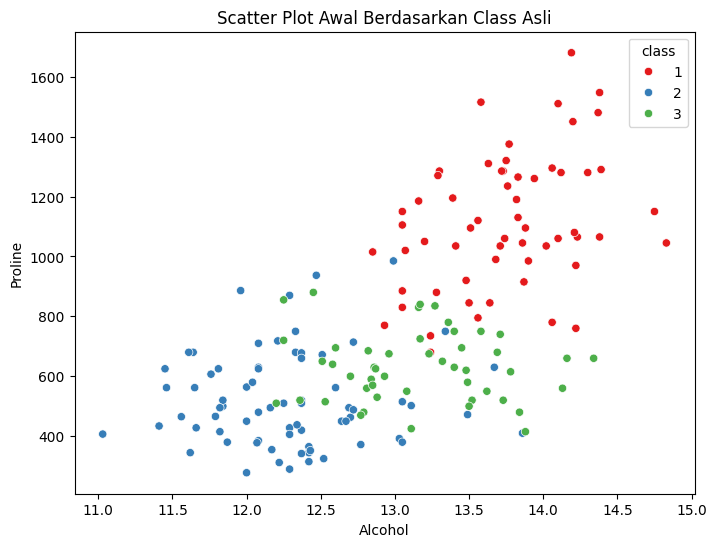

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Alcohol'],
    y=df['Proline'],
    hue=df['class'],
    palette='Set1'
)
plt.title('Scatter Plot Awal Berdasarkan Class Asli')
plt.show()

Adanya pola pemisahan awal antar kelas wine berdasarkan fitur Alcohol dan Proline. Kelas 1 (merah) cenderung terkonsentrasi pada nilai Alcohol dan Proline yang lebih tinggi, mengindikasikan karakteristik kimia yang berbeda dibanding kelompok lain. Kelas 2 (biru) banyak berada pada rentang Alcohol dan Proline yang lebih rendah, sedangkan kelas 3 (hijau) cenderung berada di area menengah dan sebagian tumpang tindih dengan kelas lain. Meskipun terdapat overlap antar kelompok, pola sebaran ini menunjukkan adanya indikasi struktur alami dalam data

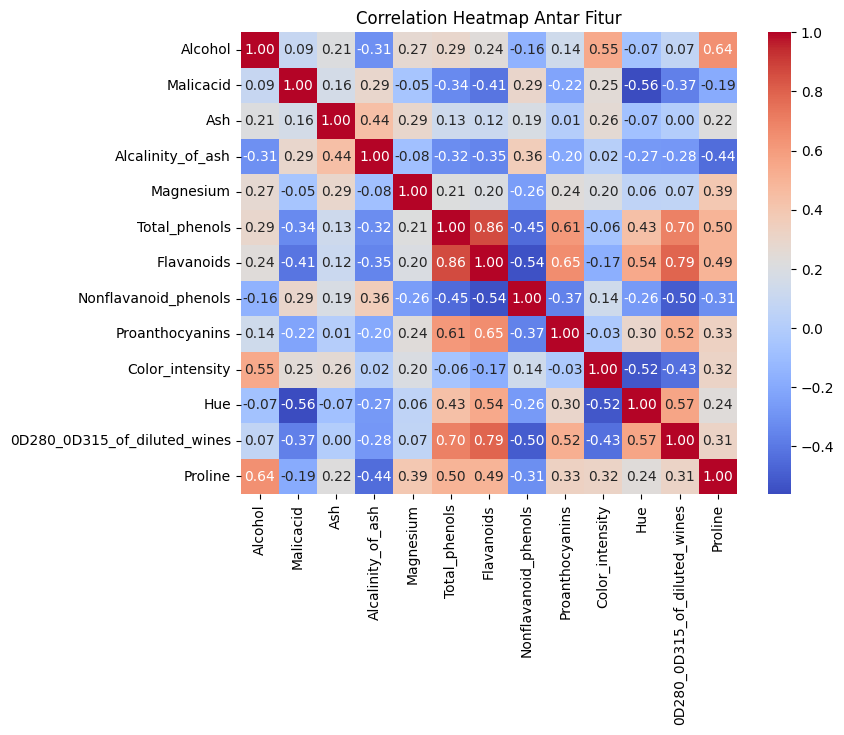

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap Antar Fitur')
plt.show()

Heatmap menunjukkan adanya hubungan kuat antar fitur yang mendukung proses clustering. Korelasi positif tinggi terlihat pada Total Phenols–Flavanoids (0.86), Flavanoids–OD280/OD315 (0.79), dan Alcohol–Proline (0.64), menandakan beberapa fitur merepresentasikan karakteristik kimia yang saling berkaitan. Terdapat juga korelasi negatif cukup kuat seperti Malic Acid–Hue (-0.56) dan Flavanoids–Nonflavanoid Phenols (-0.54) yang menunjukkan hubungan berlawanan antar fitur. Pola ini mengindikasikan data memiliki struktur alami yang baik untuk clustering serta mendukung perlunya scaling/PCA pada preprocessing.



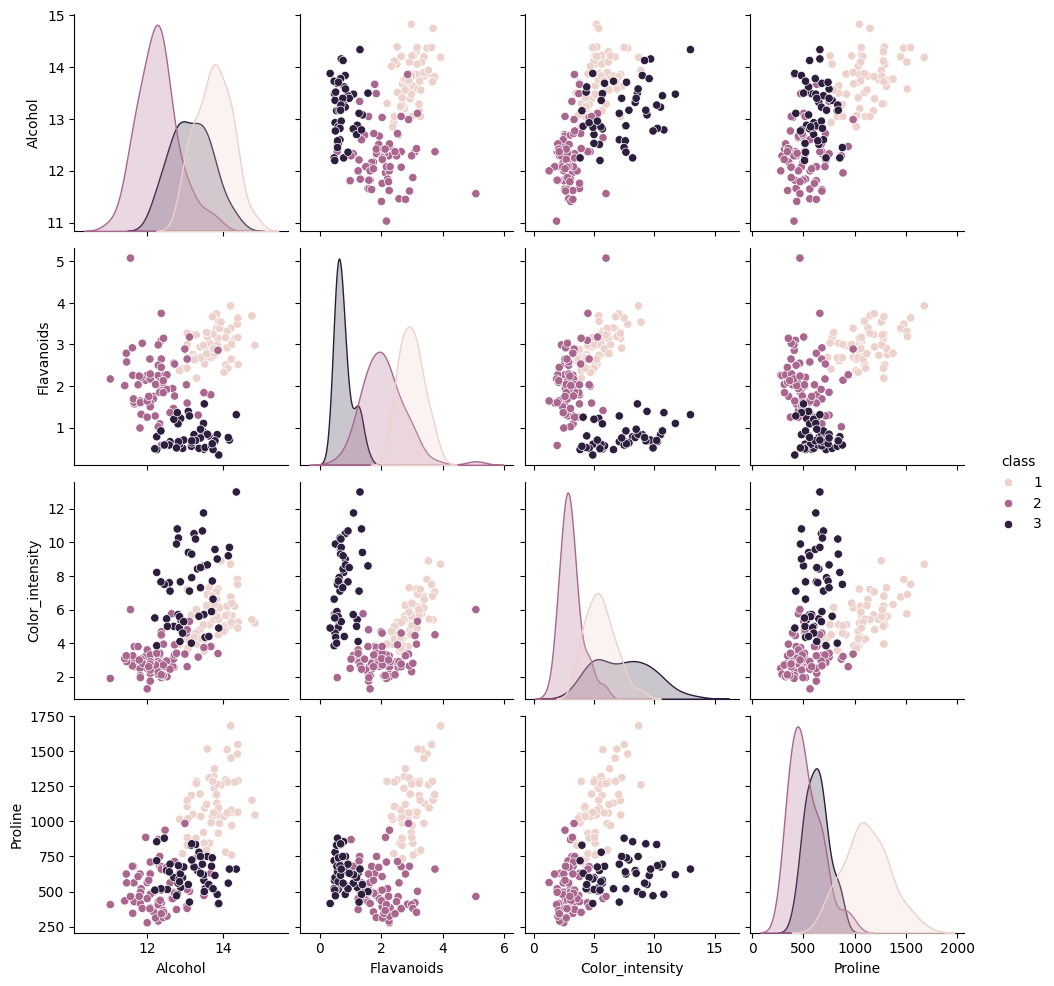

In [ ]:
sns.pairplot(
    df[['Alcohol','Flavanoids','Color_intensity','Proline','class']],
    hue='class'
)
plt.show()

Pada ketiga kelas wine memiliki pola sebaran yang cukup terpisah, terutama pada fitur Flavanoids, Color Intensity, Alcohol, dan Proline sehingga berpotensi membentuk cluster yang baik. Class 1 cenderung memiliki Alcohol dan Proline tinggi, Class 3 memiliki Color Intensity lebih tinggi, sedangkan Class 2 berada di rentang menengah.

# Clustering

## K-Means

Elbow vs Silhouette

In [ ]:
# range k
k_range_elbow = range(1, 11)
k_range_sil = range(2, 7)

inertia = []
sil_scores = []

# hitung inertia (Elbow)
for k in k_range_elbow:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# hitung silhouette
for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

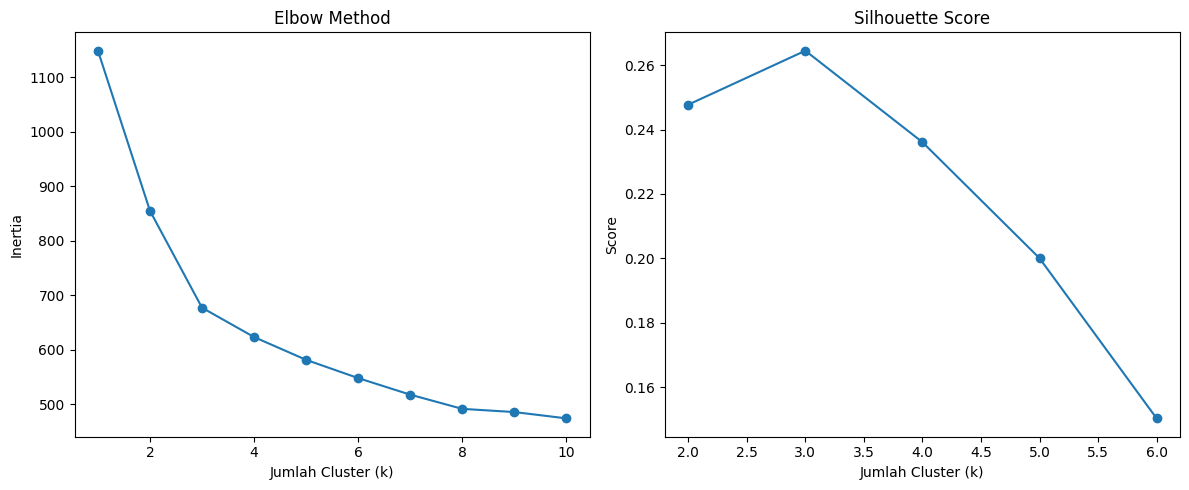

In [ ]:
plt.figure(figsize=(12,5))

# Elbow
plt.subplot(1,2,1)
plt.plot(k_range_elbow, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')

# Silhouette
plt.subplot(1,2,2)
plt.plot(k_range_sil, sil_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

Grafik Elbow menunjukkan penurunan inertia yang signifikan hingga k=3, kemudian melandai. Hal ini mengindikasikan titik optimal berada di sekitar k=3. Hal ini diperkuat oleh grafik Silhouette Score yang menunjukkan nilai tertinggi juga pada k=3, sehingga pemilihan jumlah cluster menjadi lebih valid karena didukung oleh dua metode evaluasi.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# tambah ke dataframe
X_kmeans = X_scaled.copy()
X_kmeans['Cluster'] = kmeans_labels

X_kmeans

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,Cluster
0,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050,2
1,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090,2
2,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728,2
3,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603,2
4,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.501901,2.557432,0.258993,0.232558,-0.157895,-0.638298,-0.913174,1.074627,-0.707143,1.010067,-0.962963,-0.843813,0.137255,1
174,0.266160,1.381757,0.345324,0.813953,0.210526,-0.524823,-0.829341,0.537313,-0.207143,0.875839,-0.785185,-0.989858,0.157895,1
175,0.167300,1.631757,-0.287770,0.116279,1.157895,-0.723404,-0.865269,0.537313,-0.292857,1.848993,-1.111111,-0.989858,0.333333,1
176,0.091255,0.489865,0.028777,0.116279,1.157895,-0.666667,-0.871257,1.134328,-0.135714,1.546980,-1.081481,-0.941176,0.343653,1


Model K-Means diterapkan dengan 3 cluster sesuai hasil Elbow Method, lalu setiap data diberi label cluster (0,1,2). Output menampilkan data hasil scaling yang telah ditambahkan kolom Cluster.

In [ ]:
# Profil tiap cluster
cluster_profile = X.copy()
cluster_profile['Cluster'] = kmeans_labels

print("Rata-rata tiap fitur per cluster:")
cluster_summary = (
    cluster_profile
    .groupby('Cluster')
    .mean()
    .round(2)
)
display(cluster_summary)

Rata-rata tiap fitur per cluster:


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
Cluster,,,,,,,,,,,,,
0,12.25,1.92,2.24,20.20,91.13,2.26,2.07,0.36,1.59,2.97,1.06,2.81,503.06
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.63,1.97,2.45,17.41,109.08,2.82,2.96,0.29,1.94,5.38,1.07,3.15,1088.78


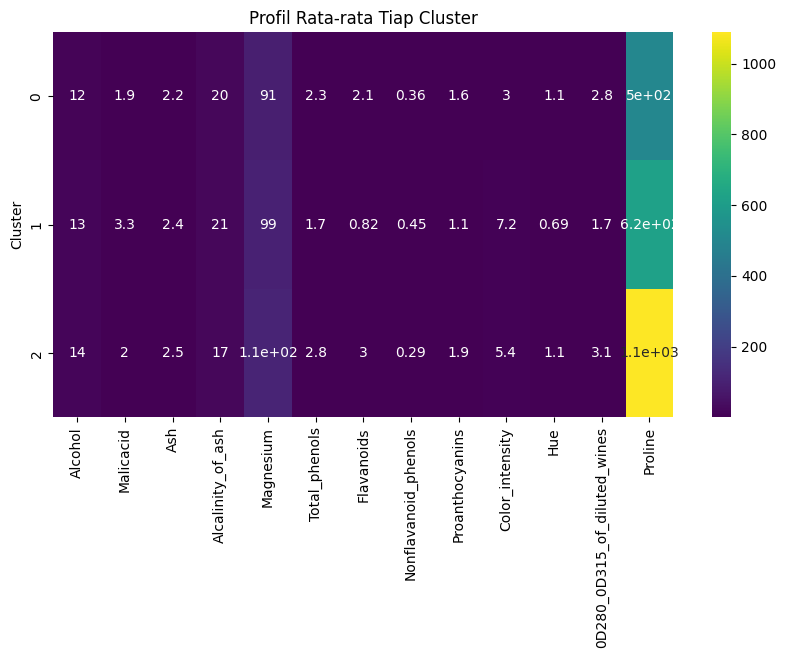

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(cluster_summary, annot=True, cmap='viridis')
plt.title('Profil Rata-rata Tiap Cluster')
plt.show()

Berdasarkan hasil K-Means dengan 3 cluster, data wine berhasil dikelompokkan menjadi tiga segmen berdasarkan kemiripan profil kimia. Cluster 0 merepresentasikan wine dengan karakteristik kimia sedang atau seimbang, Cluster 1 cenderung menunjukkan wine dengan intensitas warna lebih tinggi dan profil kimia lebih kuat, sedangkan Cluster 2 cenderung memiliki kandungan alkohol, flavanoids, dan proline lebih tinggi yang mengarah pada profil wine berkualitas tinggi/premium. Sehingga, hasil clustering menunjukkan adanya segmentasi wine berdasarkan profil kimia, sehingga dapat dimanfaatkan untuk quality grouping, product characterization, atau membantu identifikasi varietas wine berdasarkan kemiripan karakteristiknya.

In [ ]:
print("\nJumlah anggota tiap cluster:")
print(pd.Series(kmeans_labels).value_counts().sort_index())


Jumlah anggota tiap cluster:
0    63
1    51
2    64
Name: count, dtype: int64


Hasil K-Means membagi 178 data wine ke dalam 3 cluster yang relatif seimbang, yaitu Cluster 0 sebanyak 63 data, Cluster 1 sebanyak 51 data, dan Cluster 2 sebanyak 64 data. Distribusi ini menunjukkan tidak ada cluster yang terlalu dominan atau terlalu kecil, sehingga segmentasi cukup baik.

In [ ]:
print("Silhouette KMeans:",
      silhouette_score(X_scaled, kmeans_labels))

Silhouette KMeans: 0.26446733931202676


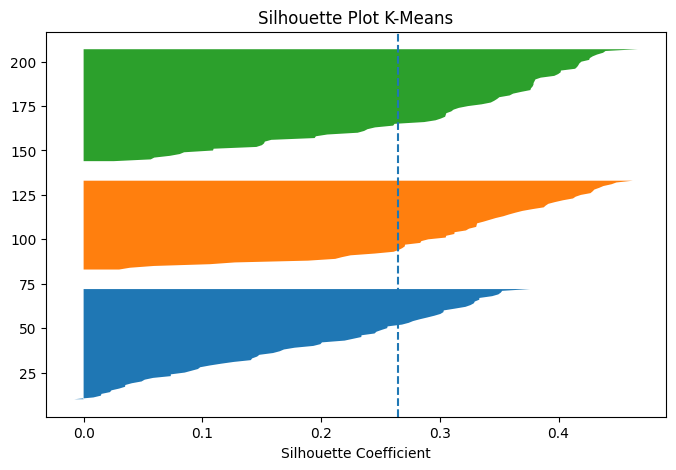

In [ ]:
sample_sil = silhouette_samples(X_scaled, kmeans_labels)

plt.figure(figsize=(8,5))
y_lower = 10

for i in range(3):
    vals = sample_sil[kmeans_labels==i]
    vals.sort()
    size = len(vals)
    y_upper = y_lower + size

    plt.fill_betweenx(
        np.arange(y_lower,y_upper),
        0,
        vals
    )

    y_lower = y_upper + 10

plt.axvline(
    x=silhouette_score(X_scaled,kmeans_labels),
    linestyle='--'
)

plt.title('Silhouette Plot K-Means')
plt.xlabel('Silhouette Coefficient')
plt.show()

Silhouette plot menunjukkan mayoritas data memiliki nilai silhouette positif, menandakan sebagian besar observasi telah masuk ke cluster yang sesuai. Garis rata-rata sekitar 0,264 menunjukkan kualitas cluster berada pada tingkat moderat, dengan pemisahan cluster cukup baik meski belum sangat kuat. Sebaran tiap cluster juga relatif konsisten dan minim nilai negatif, sehingga hasil clustering K-Means dapat dianggap cukup stabil untuk segmentasi data wine.


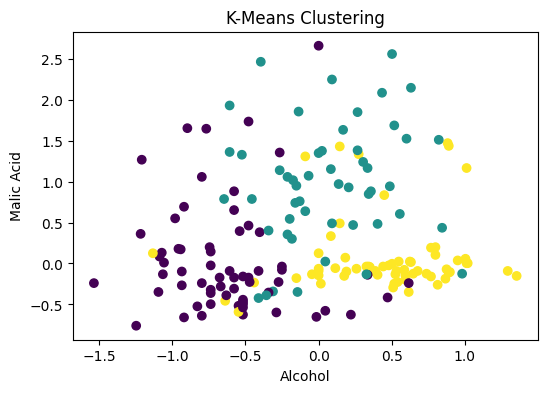

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_scaled['Alcohol'], X_scaled['Malicacid'], c=kmeans_labels)
plt.title('K-Means Clustering')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()

Menunjukkan data berhasil terbagi menjadi 3 cluster berdasarkan variabel Alcohol dan Malic Acid. Cluster ungu cenderung memiliki kadar alkohol lebih rendah dengan malic acid rendah, cluster hijau memiliki malic acid lebih tinggi, sedangkan cluster kuning didominasi kadar alkohol lebih tinggi dengan malic acid relatif rendah.

## HIERARCHICAL CLUSTERING

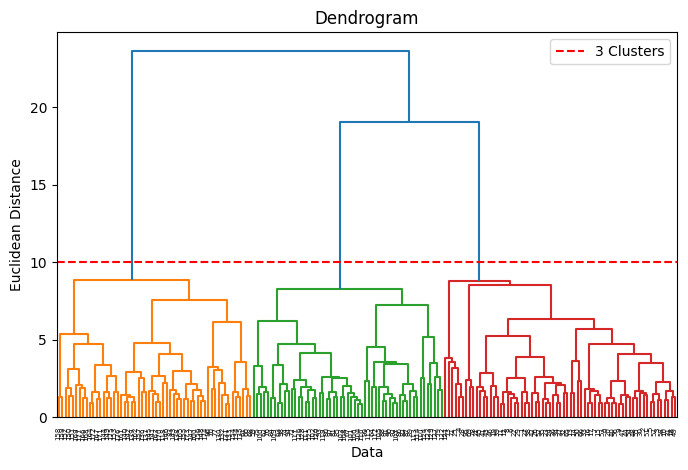

In [ ]:
plt.figure(figsize=(8,5))

dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))

plt.axhline(y=10, color='red', linestyle='--', label='3 Clusters')
plt.title('Dendrogram')
plt.xlabel('Data')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.show()

Proses penggabungan data pada metode Hierarchical Clustering menggunakan metode Ward linkage. Garis horizontal merah pada jarak Euclidean sekitar 10 digunakan sebagai batas pemotongan untuk membentuk 3 cluster utama. Terlihat bahwa data terbagi menjadi tiga kelompok yang cukup jelas karena jarak antar cluster relatif besar sebelum terjadi penggabungan akhir. Dengan keterangan warna orange sebagai cluster 1, warna hijau sebagai cluster 2, warna merah sebagai cluster 3.

In [ ]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

X_hc = X.copy()
X_hc['Cluster'] = hc_labels
X_hc.groupby('Cluster').mean().round(2)

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
Cluster,,,,,,,,,,,,,
0,13.06,3.17,2.41,21.00,99.86,1.69,0.85,0.45,1.13,6.85,0.72,1.73,624.95
1,13.61,1.94,2.44,17.50,108.10,2.82,2.96,0.29,1.95,5.34,1.08,3.14,1063.76
2,12.20,1.98,2.23,20.39,89.44,2.27,2.10,0.36,1.62,2.89,1.05,2.87,485.05


In [ ]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)
hc_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 0, 2, 2, 2, 1,
       1, 2, 0, 1, 0, 1, 2, 1, 2, 2, 2, 0, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

Hierarchical Clustering dengan 3 cluster menghasilkan segmentasi wine yang konsisten dengan K-Means, yaitu tiga kelompok utama: wine berkualitas tinggi (kandungan phenol dan flavanoid tinggi), wine dengan karakter kuat namun kualitas kimia rendah, serta wine dengan profil seimbang. Hal ini menunjukkan bahwa struktur alami data memang terbagi menjadi tiga kelompok utama berdasarkan komposisi kimianya.

In [ ]:
print("Silhouette Score Hierarchical:", silhouette_score(X_scaled, hc_labels))

Silhouette Score Hierarchical: 0.25629277931916994


Nilai Silhouette Score sebesar 0.256 menunjukkan bahwa hasil clustering Hierarchical cukup baik dalam memisahkan data, meskipun masih terdapat beberapa overlap antar cluster. Jika dibandingkan dengan K-Means yang memiliki nilai sedikit lebih tinggi (0.264), K-Means memberikan performa yang sedikit lebih optimal. Namun, perbedaan yang kecil menunjukkan bahwa kedua metode mampu menangkap struktur alami data yang sama, yaitu terbagi menjadi tiga kelompok utama.

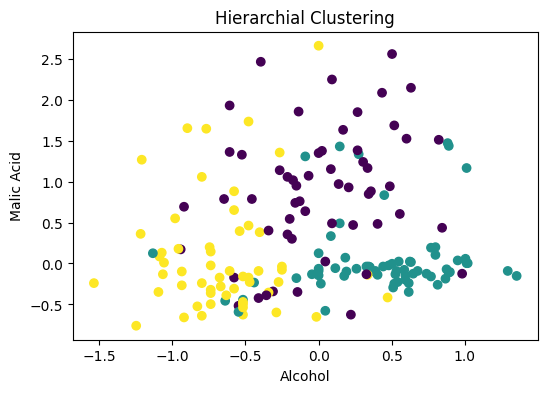

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_scaled['Alcohol'], X_scaled['Malicacid'], c=hc_labels)
plt.title('Hierarchial Clustering')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()

## DBSCAN

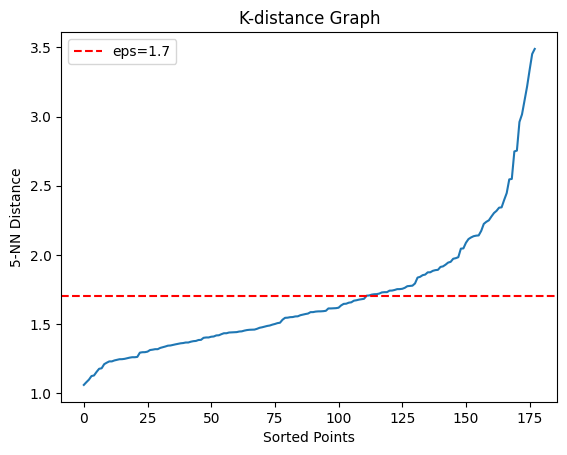

In [ ]:
neighbors = NearestNeighbors(n_neighbors=5)
nbrs = neighbors.fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

distances = np.sort(distances[:,4])

plt.plot(distances)
plt.axhline(y=1.7, color='red', linestyle='--', label='eps=1.7')
plt.title("K-distance Graph")
plt.xlabel("Sorted Points")
plt.ylabel("5-NN Distance")
plt.legend()
plt.show()

justifikasi pemilihan parameter DBSCAN

In [ ]:
eps_values = np.arange(1.2, 2.1, 0.1)
min_samples_values = range(3, 20, 2)

results = []
total_data = len(X_scaled)

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)
        noise_pct = (noise / total_data) * 100

        if n_clusters >= 2:
            results.append((eps, min_s, n_clusters, noise, noise_pct))

# urutkan berdasarkan noise terkecil
results = sorted(results, key=lambda x: x[3])

# tampilkan hasil
for r in results:
    print(f"eps={r[0]}, min_samples={r[1]}, clusters={r[2]}, noise={r[3]} ({r[4]:.1f}%)")

eps=2.000000000000001, min_samples=15, clusters=2, noise=22 (12.4%)
eps=1.9000000000000006, min_samples=11, clusters=2, noise=24 (13.5%)
eps=2.000000000000001, min_samples=17, clusters=2, noise=24 (13.5%)
eps=1.9000000000000006, min_samples=13, clusters=2, noise=27 (15.2%)
eps=1.7000000000000004, min_samples=3, clusters=3, noise=28 (15.7%)
eps=2.000000000000001, min_samples=19, clusters=2, noise=28 (15.7%)
eps=1.8000000000000005, min_samples=9, clusters=2, noise=34 (19.1%)
eps=1.9000000000000006, min_samples=15, clusters=2, noise=34 (19.1%)
eps=1.7000000000000004, min_samples=5, clusters=2, noise=35 (19.7%)
eps=1.9000000000000006, min_samples=17, clusters=2, noise=35 (19.7%)
eps=1.6000000000000003, min_samples=3, clusters=2, noise=40 (22.5%)
eps=1.8000000000000005, min_samples=11, clusters=2, noise=40 (22.5%)
eps=1.9000000000000006, min_samples=19, clusters=2, noise=41 (23.0%)
eps=1.7000000000000004, min_samples=7, clusters=2, noise=42 (23.6%)
eps=1.8000000000000005, min_samples=13, cl

In [ ]:
dbscan = DBSCAN(eps=1.6, min_samples=5) #dipilih
db_labels = dbscan.fit_predict(X_scaled)

# jumlah cluster (tanpa noise)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

# jumlah noise
n_noise = list(db_labels).count(-1)

print("Jumlah cluster:", n_clusters)
print("Jumlah noise:", n_noise)
print("Persentase noise:", round(n_noise/len(db_labels)*100,2), "%")

Jumlah cluster: 3
Jumlah noise: 49
Persentase noise: 27.53 %


In [ ]:
dbscan = DBSCAN(eps=1.6, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

X_db = X_scaled.copy()
X_db['Cluster'] = db_labels

X_db

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,Cluster
0,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050,0
1,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090,0
2,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728,0
3,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603,0
4,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.501901,2.557432,0.258993,0.232558,-0.157895,-0.638298,-0.913174,1.074627,-0.707143,1.010067,-0.962963,-0.843813,0.137255,2
174,0.266160,1.381757,0.345324,0.813953,0.210526,-0.524823,-0.829341,0.537313,-0.207143,0.875839,-0.785185,-0.989858,0.157895,2
175,0.167300,1.631757,-0.287770,0.116279,1.157895,-0.723404,-0.865269,0.537313,-0.292857,1.848993,-1.111111,-0.989858,0.333333,2
176,0.091255,0.489865,0.028777,0.116279,1.157895,-0.666667,-0.871257,1.134328,-0.135714,1.546980,-1.081481,-0.941176,0.343653,-1


In [ ]:
print("\nJumlah anggota tiap cluster:")
print(pd.Series(db_labels).value_counts().sort_index())


Jumlah anggota tiap cluster:
-1    49
 0    92
 1    13
 2    24
Name: count, dtype: int64


DBSCAN menghasilkan 3 cluster utama dengan tambahan 49 data yang dikategorikan sebagai noise (label -1), menunjukkan bahwa sebagian data tidak termasuk dalam area kepadatan tertentu.

In [ ]:
score = silhouette_score(X_scaled, db_labels)
print("Silhouette Score:", score)

Silhouette Score: 0.0736688857296667


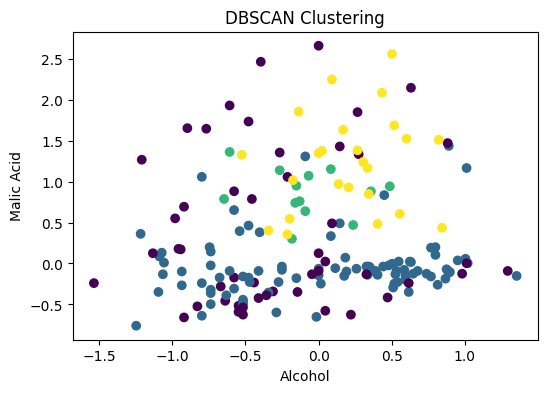

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_scaled['Alcohol'], X_scaled['Malicacid'], c=db_labels)
plt.title('DBSCAN Clustering')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()

Hasil DBSCAN menunjukkan performa yang kurang optimal dibanding metode lain, ditunjukkan oleh nilai Silhouette Score yang rendah (0.07) dan jumlah noise yang cukup tinggi (~27%). Hal ini mengindikasikan bahwa struktur data wine tidak sepenuhnya berbentuk cluster berbasis densitas yang jelas.

DBSCAN cenderung sensitif terhadap pemilihan parameter eps dan min_samples, serta kurang cocok untuk data dengan distribusi yang relatif merata seperti dataset ini. Akibatnya, banyak data dianggap sebagai noise dan cluster yang terbentuk kurang representatif.

Oleh karena itu, DBSCAN tidak direkomendasikan sebagai metode utama untuk dataset ini, dibandingkan K-Means atau metode lain yang memberikan hasil lebih stabil.

### Clustering lanjutan

## Fuzzy C-Means

In [ ]:
X_fcm = X_scaled.T.values

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_fcm,
    c=3,           # jumlah cluster
    m=2,           # fuzziness
    error=0.005,
    maxiter=1000
)

fcm_labels = np.argmax(u, axis=0)

X_fcm = X_scaled.copy()
X_fcm['Cluster'] = fcm_labels

X_fcm

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,Cluster
0,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050,2
1,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090,2
2,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728,2
3,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603,2
4,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.501901,2.557432,0.258993,0.232558,-0.157895,-0.638298,-0.913174,1.074627,-0.707143,1.010067,-0.962963,-0.843813,0.137255,1
174,0.266160,1.381757,0.345324,0.813953,0.210526,-0.524823,-0.829341,0.537313,-0.207143,0.875839,-0.785185,-0.989858,0.157895,1
175,0.167300,1.631757,-0.287770,0.116279,1.157895,-0.723404,-0.865269,0.537313,-0.292857,1.848993,-1.111111,-0.989858,0.333333,1
176,0.091255,0.489865,0.028777,0.116279,1.157895,-0.666667,-0.871257,1.134328,-0.135714,1.546980,-1.081481,-0.941176,0.343653,1


In [ ]:
print("\nJumlah anggota tiap cluster:")
print(pd.Series(fcm_labels).value_counts().sort_index())


Jumlah anggota tiap cluster:
0    63
1    52
2    63
Name: count, dtype: int64


In [ ]:
score_fcm = silhouette_score(X_scaled, fcm_labels)

print("Silhouette FCM:", score_fcm)

Silhouette FCM: 0.26210898386881704


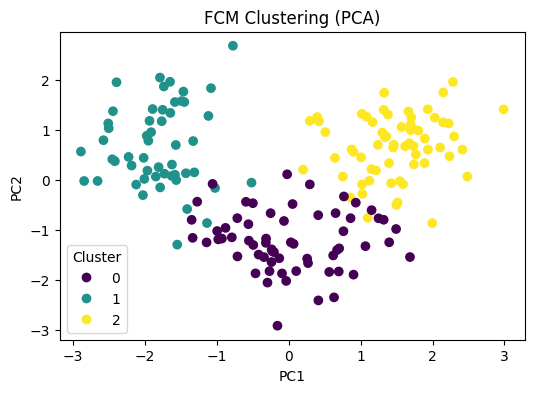

In [ ]:
plt.figure(figsize=(6,4))
scatter = plt.scatter(X_vis['PC1'], X_vis['PC2'], c=fcm_labels)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title('FCM Clustering (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## Spectral

In [ ]:
spectral = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    random_state=42
)

spectral_labels = spectral.fit_predict(X_scaled)
score_spectral = silhouette_score(X_scaled, spectral_labels)

X_spectral = X_scaled.copy()
X_spectral['Cluster'] = spectral_labels

X_spectral

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,Cluster
0,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050,1
1,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090,1
2,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728,1
3,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603,1
4,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.501901,2.557432,0.258993,0.232558,-0.157895,-0.638298,-0.913174,1.074627,-0.707143,1.010067,-0.962963,-0.843813,0.137255,0
174,0.266160,1.381757,0.345324,0.813953,0.210526,-0.524823,-0.829341,0.537313,-0.207143,0.875839,-0.785185,-0.989858,0.157895,0
175,0.167300,1.631757,-0.287770,0.116279,1.157895,-0.723404,-0.865269,0.537313,-0.292857,1.848993,-1.111111,-0.989858,0.333333,0
176,0.091255,0.489865,0.028777,0.116279,1.157895,-0.666667,-0.871257,1.134328,-0.135714,1.546980,-1.081481,-0.941176,0.343653,0


In [ ]:
print("\nJumlah anggota tiap cluster:")
print(pd.Series(spectral_labels).value_counts().sort_index())


Jumlah anggota tiap cluster:
0    50
1    64
2    64
Name: count, dtype: int64


In [ ]:
print("Silhouette Spectral:", score_spectral)

Silhouette Spectral: 0.2626828075620082


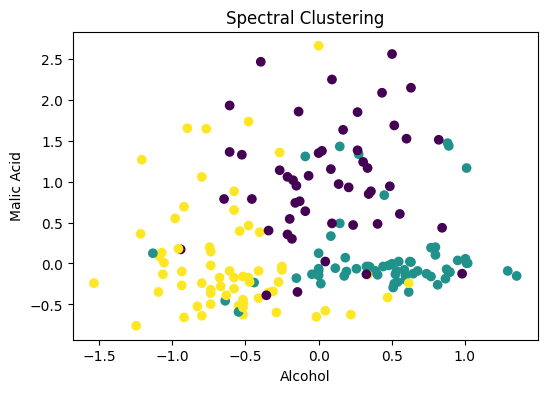

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(
    X_scaled['Alcohol'],
    X_scaled['Malicacid'],
    c=spectral_labels
)
plt.title('Spectral Clustering')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()

# Evaluasi

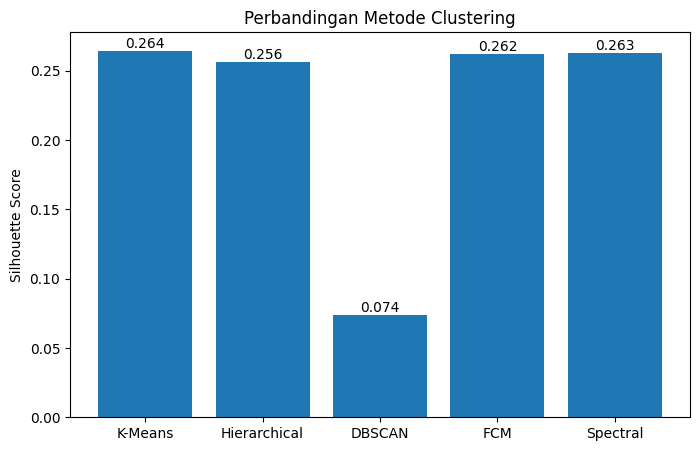

In [ ]:
methods = ['K-Means','Hierarchical','DBSCAN','FCM', 'Spectral']
scores = [
    silhouette_score(X_scaled, kmeans_labels),
    silhouette_score(X_scaled, hc_labels),
    silhouette_score(X_scaled, db_labels),
    silhouette_score(X_scaled, fcm_labels),
    silhouette_score(X_scaled, spectral_labels)
]

plt.figure(figsize=(8,5))
bars=plt.bar(methods,scores)

for b in bars:
    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height()+0.002,
        round(b.get_height(),3),
        ha='center'
    )

plt.ylabel('Silhouette Score')
plt.title('Perbandingan Metode Clustering')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


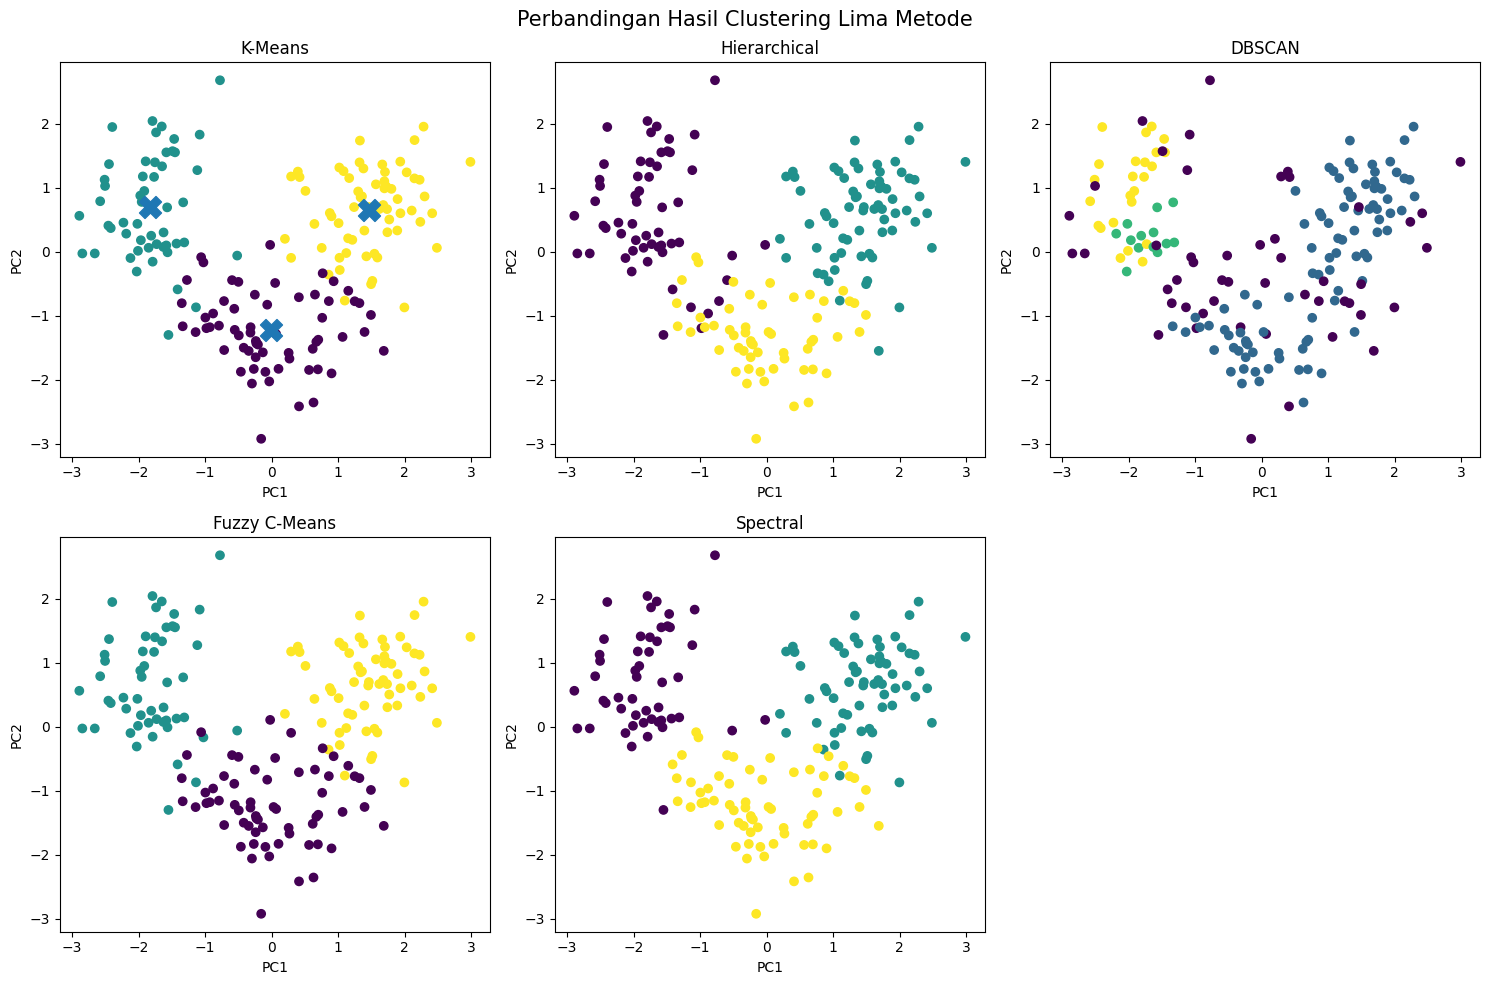

In [ ]:
# PCA untuk visualisasi 2D
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2,3, figsize=(15,10))
axes = axes.flatten()

# 1 K-Means
axes[0].scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=kmeans_labels
)
# centroid KMeans
centers = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(
    centers[:,0],
    centers[:,1],
    marker='X',
    s=250
)
axes[0].set_title('K-Means')

# 2 Hierarchical
axes[1].scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=hc_labels
)
axes[1].set_title('Hierarchical')

# 3 DBSCAN
axes[2].scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=db_labels
)
axes[2].set_title('DBSCAN')

# 4 Fuzzy C-Means
axes[3].scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=fcm_labels
)
axes[3].set_title('Fuzzy C-Means')

# 5 Spectral
axes[4].scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=spectral_labels
)
axes[4].set_title('Spectral')

# subplot kosong terakhir dihapus
fig.delaxes(axes[5])

for ax in fig.axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle(
    'Perbandingan Hasil Clustering Lima Metode',
    fontsize=15
)

plt.tight_layout()
plt.show()

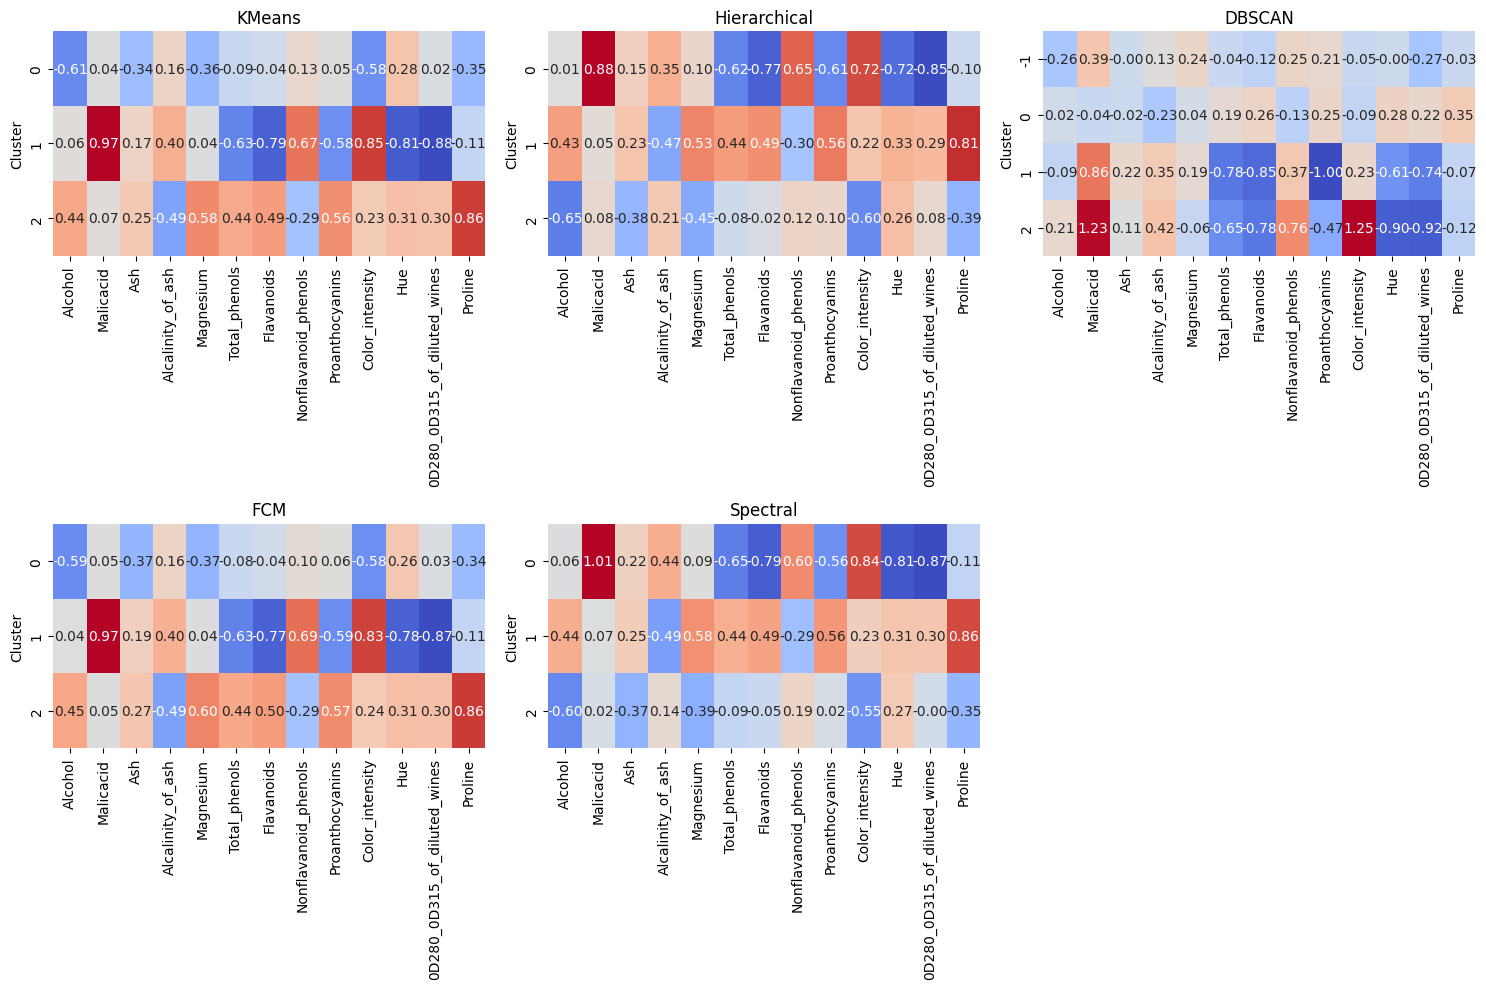

In [ ]:
methods_labels = {
    'KMeans': kmeans_labels,
    'Hierarchical': hc_labels,
    'DBSCAN': db_labels,
    'FCM': fcm_labels,
    'Spectral': spectral_labels
}

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten() # Flatten the 2D array of axes

for ax, (name, labels) in zip(axes, methods_labels.items()):
    temp = X_scaled.copy()
    temp['Cluster'] = labels

    summary = temp.groupby('Cluster').mean()

    sns.heatmap(
        summary,
        cmap='coolwarm',
        annot=True,      # 🔥 tampilkan angka
        fmt='.2f',       # 2 angka di belakang koma
        ax=ax,
        cbar=False
    )

    ax.set_title(name)

# Hide any unused subplots if methods_labels has fewer than 2x3 items
for i in range(len(methods_labels), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

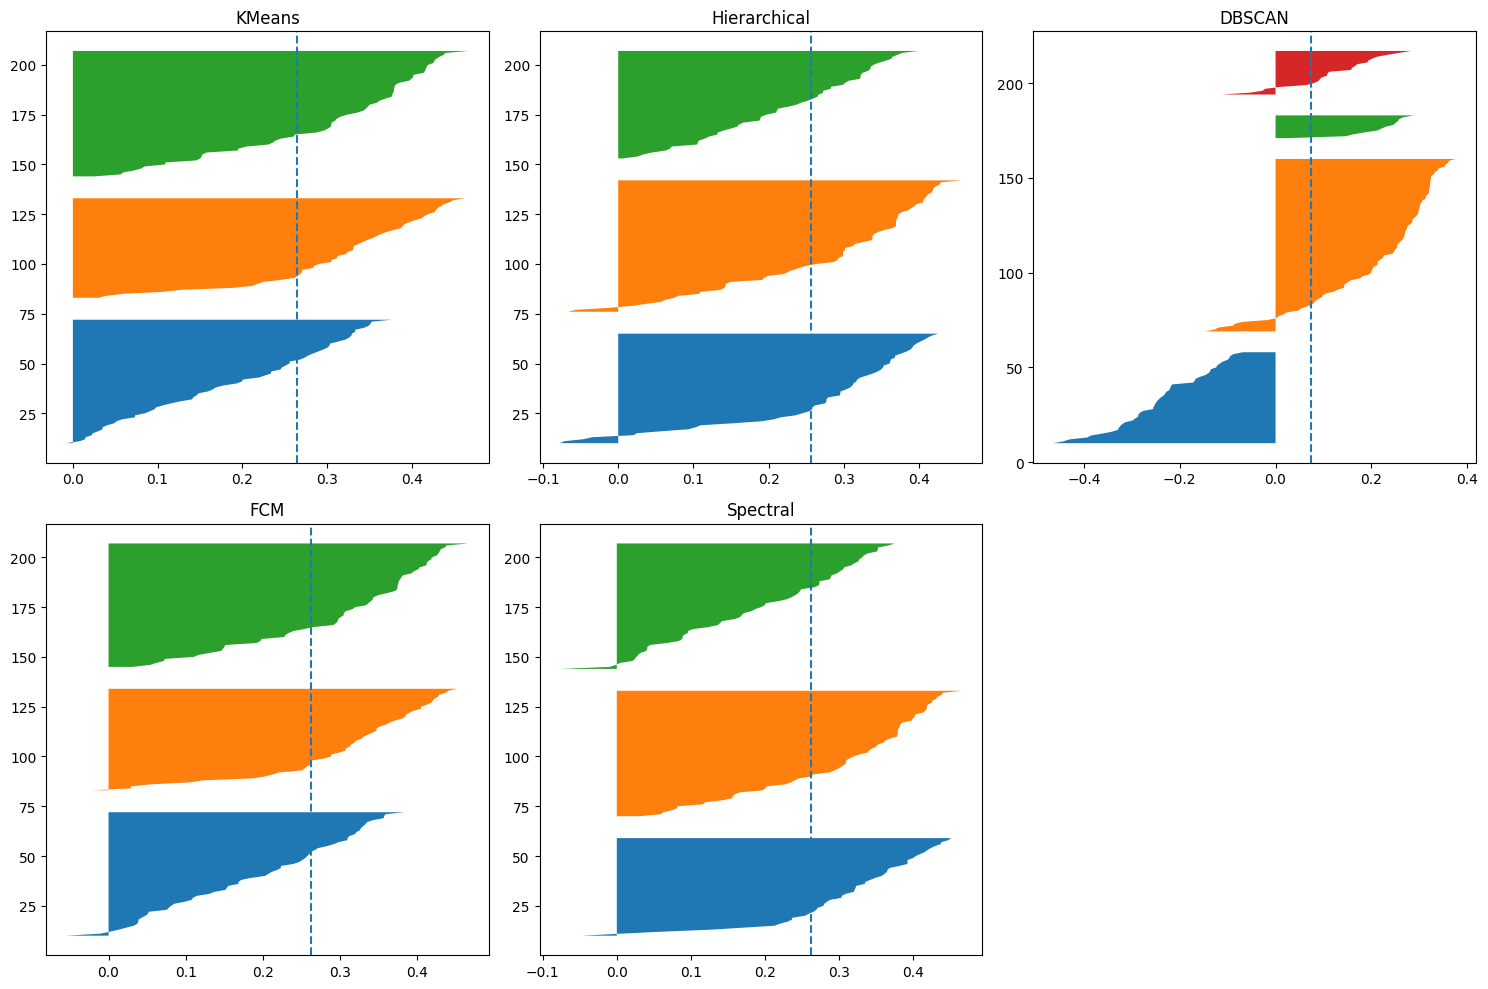

In [ ]:
plt.figure(figsize=(15,10))

methods = [
    ('KMeans', kmeans_labels),
    ('Hierarchical', hc_labels),
    ('DBSCAN', db_labels),
    ('FCM', fcm_labels),
    ('Spectral', spectral_labels)
]

for idx, (name, labels) in enumerate(methods):
    plt.subplot(2,3,idx+1)

    sample_sil = silhouette_samples(X_scaled, labels)
    y_lower = 10

    for i in np.unique(labels):
        vals = sample_sil[labels==i]
        vals.sort()
        size = len(vals)
        y_upper = y_lower + size

        plt.fill_betweenx(
            np.arange(y_lower,y_upper),
            0,
            vals
        )
        y_lower = y_upper + 10

    plt.axvline(
        x=silhouette_score(X_scaled, labels),
        linestyle='--'
    )
    plt.title(name)

plt.tight_layout()
plt.show()

# DASBOARD